# Применение ML для метчинга в A/B-тестах

## Введение и постановка проблемы

A/B-тестирование - это частный случай статистической проверки гипотез. Чтобы проверить любые предположения математически, сначала нужно переформулировать их в чёткие проверяемые утверждения:

- **Нулевая гипотеза,** обозначается $H_0$
- **Альтернативная гипотеза,** обозначается $H_1$

**Нулевая гипотеза** формулируется как **утверждение, которое необходимо проверить**. Чаще всего в качестве нулевой гипотезы формулируют утверждение про отсутствие связи, отсутствие отличий, отсутствие какого-то явления.

**Альтернативная гипотеза** обычно соответствует предположению, что связь, отличия или какое-то явление — есть.

Нулевая гипотеза считается истиной «по умолчанию», то есть до тех пор, пока данные не предоставят убедительных доказательств против неё.

Особенностью A/B-тестирования является то, что здесь всегда имеют место две группы - **тестовая** и **контрольная**:

- **Тестовая группа** - испытуемые, на которых оказывается определенное воздействие
- **Контрольная группа** - испытуемые, на которых никакого воздействия не оказывается

При  условии, что различие между группами проявляется только в том эффекте, который мы хотим проверить, отвержение нулевой гипотезы об отсутствии значимых различий между A и B будет свидетельствовать о том, что наше воздействие действительно чего-то стоит.

In [ ]:
# !pip install kagglehub
import kagglehub
import pandas as pd
import os

path_1 = kagglehub.dataset_download("amirmotefaker/ab-testing-dataset")

control = pd.read_csv(os.path.join(path_1, 'control_group.csv'), sep=';').fillna(0)
test = pd.read_csv(os.path.join(path_1, 'test_group.csv'), sep=';').fillna(0)
test.head(3)

In [ ]:
from scipy.stats import ttest_ind
import numpy as np

In [ ]:
alpha = 0.05
metric = "# of Add to Cart"

print('Тест (среднее): ', np.around(test[metric].mean(),3))
print('Контроль (среднее): ', np.around(control[metric].mean(),3), end='\n---\n')

stat, p = ttest_ind(test[metric], control[metric],  equal_var=False,
                    nan_policy='propagate', alternative='less')

print(f"statistic: {stat}")
print(f"p_value: {np.around(p,5)}", end='\n---\n')

if p < alpha:
    print('-> Отвергаем H-0')
else:
    print('-> Не можем отвергнуть H-0')

В приведенном примере мы сравниваем средние значения показателя *metric* между двумя выборками и получаем статистически значимые различия, которые свидетельствуют о том, что изменения, произведенные в тестовой группе, привели к снижению количества добавивших в корзину.

Однако перед тем, как провести такого рода эксперимент, необходимо **корректно выбрать группы**, которые будут сравниваться, поскольку, в противном случае, на тест будут влиять **внешние факторы** и его результаты будут **нерепрезентативными**.

## Простые подходы к формированию групп

**Ключевые требования**, которые предъявляются к выборкам в A/B-тесте следующие:

- Сбалансированность по ключевым признакам
- Независимость наблюдаемых и отсутствие пересечений между группами
- Достаточный размер выборкок
- Сопоставимый между собой и размер выборок и сохранение пропорций в ходе эксперимента
- Одинаковые условия эксперимента

In [ ]:
path = kagglehub.dataset_download("snowwlex/etsy-shops")

data = pd.read_csv(os.path.join(path, 'shops.csv'))
data['seller_location'] = data['seller_location'].fillna('-')
data.iloc[:,1:] = data.iloc[:,1:].fillna(0)
data = data.sample(1000, random_state=42).reset_index(drop=True)
data['id'] = data.index
data.head()

В большинстве случаев, решить эту задачу помогает **простая рандомизированная выборка**, при которой объекты из общей совокупности случайным образом по очереди отбираются в одну и в другую группу. Если выборки достаточно большие, можно утверждать, что в силу **закона больших чисел** такие выборки будут репрезентативными.

<div>
<img src="attachment:image.png" width="400">
</div>

In [ ]:
# Случайные непересекающиеся выборки по 500
test = data.sample(500, random_state=42)
test['group'] = 'Test'

control = data[~data['id'].isin(test['id'])].sample(500, random_state=42)
control['group'] = 'Control'

total_samples = pd.concat([test, control])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig,axes = plt.subplots(2,2,figsize=(8,8),dpi=120)
fig.suptitle('Сравнение случайных распределений',fontsize=14)

sns.histplot(ax=axes[0][0], data=total_samples, x='number_of_sales', log_scale=True, hue='group')
axes[0][0].set_title('number_of_sales',fontsize=12)
axes[0][0].set_xlabel(None)
axes[0][0].set_ylabel(None)

sns.histplot(ax=axes[0][1], data=total_samples, x='number_of_reviews', log_scale=True, hue='group')
axes[0][1].set_title('number_of_reviews',fontsize=12)
axes[0][1].set_xlabel(None)
axes[0][1].set_ylabel(None)

sns.histplot(ax=axes[1][0], data=total_samples, x='average_review_score', hue='group')
axes[1][0].set_title('average_review_score',fontsize=12)
axes[1][0].set_xlabel(None)

sns.histplot(ax=axes[1][1], data=total_samples, x='number_of_items', log_scale=True, hue='group')
axes[1][1].set_title('number_of_items',fontsize=12)
axes[1][1].set_xlabel(None)
axes[1][1].set_ylabel(None)

fig.tight_layout()

Однако встречаются ситуации, в которой простой рандомизировнной выборки может быть недостаточно. К таковым относятся:

- **Небольшие выборки**, вызванные малым количеством доступных испытуемых или **коротким периодом проведения эксперимента**  
- **Сильная неоднородность аудитории**, которая приводит к тому, что замеряемый признак серьезно отличается между сегментами
- **Наличие редких, но критичных сегментов** или выбросов, которые необходимо учесть (например, VIP, enterprise)

В таких случаях приходится прибегать к другим методам. Наиболее прямолинейный из них - **стратифицированная выборка**. При таком подходе мы вручную сегментируем имеющиеся объекты по каким-то значимым признакам, а затем из каждой группы в отдельности извлекаем тестовую и контрольную выборку.

После этого мы можем совместить их, чтобы провести один тест с равномерно распределенным по группам признаком, или провести несколько отдельных экспериментов, чтобы увидеть эффект в разрезе по группам.  

In [ ]:
import re

data['country'] = data['seller_location'].apply(lambda x: re.findall(r', (.+)', x)[-1]
                                                if len(re.findall(r', (.+)', x))>0
                                                else '-')

In [ ]:
# Сегментация по странам и по оценкам
country_stats = data.groupby('country', as_index=False).agg({'id':'count'}).sort_values(by='id')
country_stats = country_stats.rename(columns={'id':'cnt'})
top_5 = country_stats[country_stats['country']!='-'].tail()['country'].to_list()
print(top_5)
data['country_segment'] = np.where(data['country'].isin(top_5),
                                   data['country'],
                                   'Other')

data['score_segment'] = pd.cut(data['average_review_score'], 3, labels=['Мало отзывов', 'Смешанные отзывы', 'Хорошие отзывы'])
print({k:int(v) for k,v in dict(data['score_segment'].value_counts()).items()})

data['segment_fin'] = data.apply(lambda row: f"{row['country_segment']} ({row['score_segment']})", axis=1)
data.head()

In [ ]:
from sklearn.model_selection import train_test_split

control_strat, test_strat = train_test_split(
    data,
    test_size=0.5,
    random_state=42,
    stratify=data["segment_fin"]
)

In [ ]:
representation = pd.DataFrame(control_strat['segment_fin'].value_counts()).reset_index().\
    merge(pd.DataFrame(test_strat['segment_fin'].value_counts()).reset_index(),
         on='segment_fin', how='inner', suffixes=('_control','_test'))
representation.head(10)

В ряде случаев, когда один баланс классов действительно нарушен и имеет серьезное влияние на данные, стратифицированная выборка дает значительно более низкую дисперсию оценоки выборочного среднего.

In [ ]:
import scipy.stats as st

In [ ]:
syntetic = pd.DataFrame({
    'weird_sign' : st.bernoulli.rvs(p=0.1, size=1000, random_state=42),
    'goodness' : st.norm.rvs(loc=100, scale=5, size=1000, random_state=42)
})
syntetic['goodness'] = syntetic['goodness'] + syntetic['weird_sign'] * syntetic['goodness'] * 0.25
syntetic.head()

In [ ]:
# Среднее стратифицированное
class_stats = syntetic.groupby('weird_sign', as_index=False).agg(avg_goodness=('goodness','mean'),
                                                   class_volume=('weird_sign','count'))
class_stats['class_wgh'] = class_stats['class_volume'] / class_stats['class_volume'].sum()

strat_mean = class_stats['avg_goodness'] @ class_stats['class_wgh']

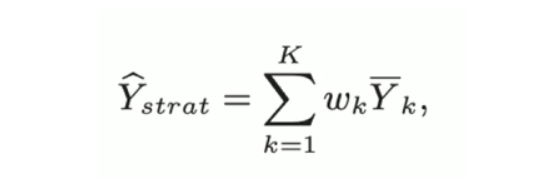

In [ ]:
stats = pd.DataFrame(columns=['vers','mean','var'])
for i in range(10_000):

    control_strat, test_strat = train_test_split(
        syntetic,
        test_size=0.5,
        stratify=syntetic["weird_sign"]
    )

    control_rand, test_rand = train_test_split(
        syntetic,
        test_size=0.5
    )

    stats.loc[len(stats)] = ['strat', control_strat['goodness'].mean(), control_strat['goodness'].var(ddof=1)]
    stats.loc[len(stats)] = ['rand', control_rand['goodness'].mean(), control_rand['goodness'].var(ddof=1)]

In [ ]:
plt.figure(figsize=(6,4), dpi=120)
plt.title('Сравнение разброса оценок среднего')
sns.histplot(data=stats, x='mean', bins=100, hue='vers')
plt.axvline(x=strat_mean, color='r', linestyle='--', linewidth=2)
plt.show()

**Дисперсия случайного семплирования** складывается из дисперсии внутри группы и дисперсии между группами:

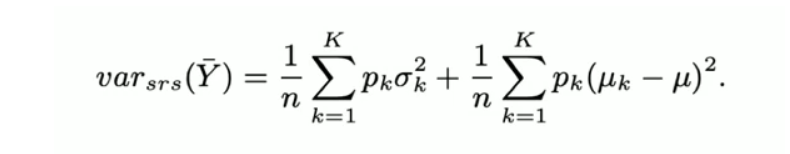

**Дисперсия стратифицированного семплирования** включает только дисперсию внутри группы и потому меньше или равна дисперсии случайного семплирования:

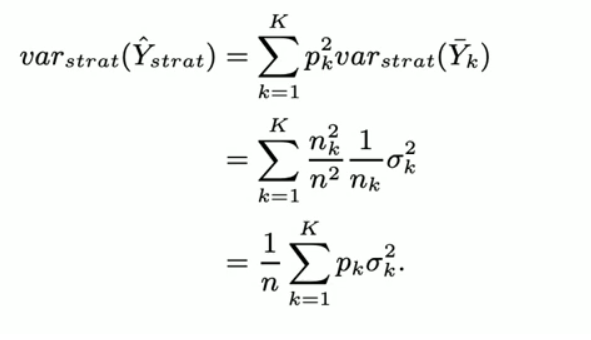

# Продвинутые методики с использованием ML

В ситуациях, котогда выделить страты при помощи какой-то бизнес-логики становится затруднительно, можно примегнуть к ML как к источнику дополнительных инсайтов об устройстве данных и закономерностях в них.

Простой пример - **кластеризация пользователей для выявления сегментов**, по которым далее будет производиться стратификация.

Это может быть полезно в ситуациях, когда присутвует сильная неоднородность аудитории, а также, когда имеется много факторов, а стратифицировать по всем вручную невозможно.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
path_2 = kagglehub.dataset_download("arjunbhasin2013/ccdata")

data_ml = pd.read_csv(os.path.join(path_2, 'CC GENERAL.csv'))
data_ml = data_ml.drop('CUST_ID', axis=1)
data_ml.head()

In [ ]:
inputer = SimpleImputer(missing_values=np.nan, strategy='median')
scaler = StandardScaler()

In [ ]:
columns = data_ml.columns
data_ml = inputer.fit_transform(data_ml)
data_ml = pd.DataFrame(scaler.fit_transform(data_ml), columns=columns)
data_ml.head(3)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [ ]:
def visualize_clusters(data, model_name, cluster_col):

    pca = PCA(n_components=0.8)

    pca_representation = pca.fit_transform(data.drop(cluster_col, axis=1))
    pca_representation = pd.DataFrame(pca_representation[:,:2], columns=['PC1', 'PC2'])
    pca_representation[cluster_col] = data[cluster_col]

    plt.figure(figsize=(6, 4), dpi=120)
    plt.title(f'2D визуализация кластеров ({model_name})')
    sns.scatterplot(data = pca_representation, x='PC1', y='PC2', hue=cluster_col)
    plt.show()

In [ ]:
k_means = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    random_state=42
)

data_ml['cluster'] = k_means.fit_predict(data_ml)
visualize_clusters(data_ml, 'K-Means', 'cluster')

In [ ]:
# Каждый кластер случайно делим пополам и собираем из получившихся срезов контрольную и тестовую группу
control_clust = pd.DataFrame()
test_clust = pd.DataFrame()

for cluster in data_ml['cluster'].unique():

    cluster_data = data_ml[data_ml['cluster']==cluster].copy()

    control, test = train_test_split(
        cluster_data,
        test_size=0.5,
        random_state=42
    )

    control_clust = pd.concat([control_clust, control]).reset_index(drop=True)
    test_clust = pd.concat([test_clust, test]).reset_index(drop=True)

In [ ]:
representation_km = pd.DataFrame(control_clust['cluster'].value_counts()).reset_index().\
    merge(pd.DataFrame(test_clust['cluster'].value_counts()).reset_index(),
         on='cluster', how='inner', suffixes=('_control','_test')).sort_values(by='cluster')
representation_km

Важно, чтобы кластеры действительно были различимы и имели досточно большой размер, чтобы на них имело смысл обращать внимание. Также, внутри кластеров обязательно нужно проводить рандомизацию.

Нельзя, чтобы среди признаков, по которым проивзодится кластеризация, имелись признаки, на которые далее будет производиться воздействие в ходе теста.

## Propensity Score Matching (PSM) для A/B-тестирования

PSM анализ – это метод Causal Inference. Метод помогает сбалансировать группы A и B по известным характеристикам, чтобы сделать их баланс одинаковым и свести на нет их влияние на зависимую переменную.

Все что вам необходимо:
- Вы хотите узнать эффект от влияния эксперимента
- Вы как-то случайно разметили группы на контроль и тест
- У вас есть данные по характеризующим переменным у контроля и теста

In [ ]:
from IPython.display import Image, display
import os

if os.path.exists('PSM_photo_1.jpg'):
    display(Image('PSM_photo_1.jpg', width=600, height=400))
else:
    print('PSM_photo_1.jpg не найден: пропускаем локальную иллюстрацию, это не влияет на расчёты.')


#### Пример
Мы запустили эксперимент по изменению цен на оффлайн-магазинах одной небольшой сети по продаже электроники. Магазины определены в контрольную и тестовую группы.

In [ ]:
from IPython.display import Image, display
import os

if os.path.exists('PSM_photo_2.jpg'):
    display(Image('PSM_photo_2.jpg', width=400, height=400))
else:
    print('PSM_photo_2.jpg ?? ??????: ?????????? ????????? ???????????, ??? ?? ?????? ?? ???????.')


Сравнить контроль с тестом можно при условии наличия гомогенной выборки. В данном случае, мы заматчили магазины таким образом, чтобы они не отличались по ряду характеристик. Итоговый показатель эффективности эксперимента будет рассчитан только по заматченным магазинам.

In [ ]:
from IPython.display import Image, display
import os

if os.path.exists('PSM_photo_3.jpg'):
    display(Image('PSM_photo_3.jpg', width=600, height=400))
else:
    print('PSM_photo_3.jpg ?? ??????: ?????????? ????????? ???????????, ??? ?? ?????? ?? ???????.')


**Основная идея PSM** – отобрать похожие пары юнитов таким образом, чтобы нивелировать влияние независимых переменных и оставить влияние только от treatment. По сути, мы создаем новые тест/контроль группы (пары могут быть не уникальны)

1. Соберите данные

2. Оценить propensity score

3. Замэтчите пары юнитов с помощью меры дистанции

4. Оставьте только похожие пары и рассчитайте целевую метрику

Как мы можем определить, **какой юнит из первой группы лучшим образом подходит к юниту из второй группы**?

Рассчитать логистическую регрессию, чтобы получить вероятность определения в treatment группу:

$Pr(Treatment=1|X_{1}, X_{2}, \dots , X_{k})$

Где $X_{k}$ – независимая переменная

Мы получим **propensity score** (вероятность определения в treatment группу). На основе его, мы можем рассчитать дистанцию между разными юнитам (магазинами) как дельту PSM, перебрав все возможные пары и выбрать ту пару, где дистанция наименьшая.

После расчета дистанции, мы замэтчим самые близкие группы.

**Плюсы:**

- Простая интерпретация

- Легкая реализация

- Понятный инструмент, в котором достаточно очевидно как происходит отладка

**Минусы:**

- Плохо масштабируется

- Неочевидно какие ковариаты нужно подобрать для мэтчинга

- Наличие зависимости, которую нужно дополнительно нивелировать

### Визуализация метода

In [ ]:
# !pip install CausalInference

In [ ]:
pd.options.display.float_format = "{:.2f}".format
sns.set(style='darkgrid', context='talk')
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score
from causalinference import CausalModel

In [ ]:
path = kagglehub.dataset_download("snowwlex/etsy-shops")

data = pd.read_csv(os.path.join(path, 'shops.csv'))
data['seller_location'] = data['seller_location'].fillna('-')
data.iloc[:,1:] = data.iloc[:,1:].fillna(0)
data = data.sample(1000, random_state=42).reset_index(drop=True)
data.head()

In [ ]:
print("Информация о датасете:")
print(f"Количество записей: {len(data)}")
print(f"Количество признаков: {len(data.columns)}")

In [ ]:
data.info()

#### Создание целевых переменных

In [ ]:
median_sales = data['number_of_sales'].median()
data['treatment'] = (data['number_of_sales'] > median_sales).astype(int)

In [ ]:
OUTCOME = 'average_review_score'
TREATMENT = 'treatment'

print(f"Медиана продаж: {median_sales:.0f}")
print(f"\nРаспределение treatment:")
print(data[TREATMENT].value_counts())
print(f"\nДоля магазинов с высокими продажами: {data[TREATMENT].mean():.3f}")

#### Демонстрация несхожести групп

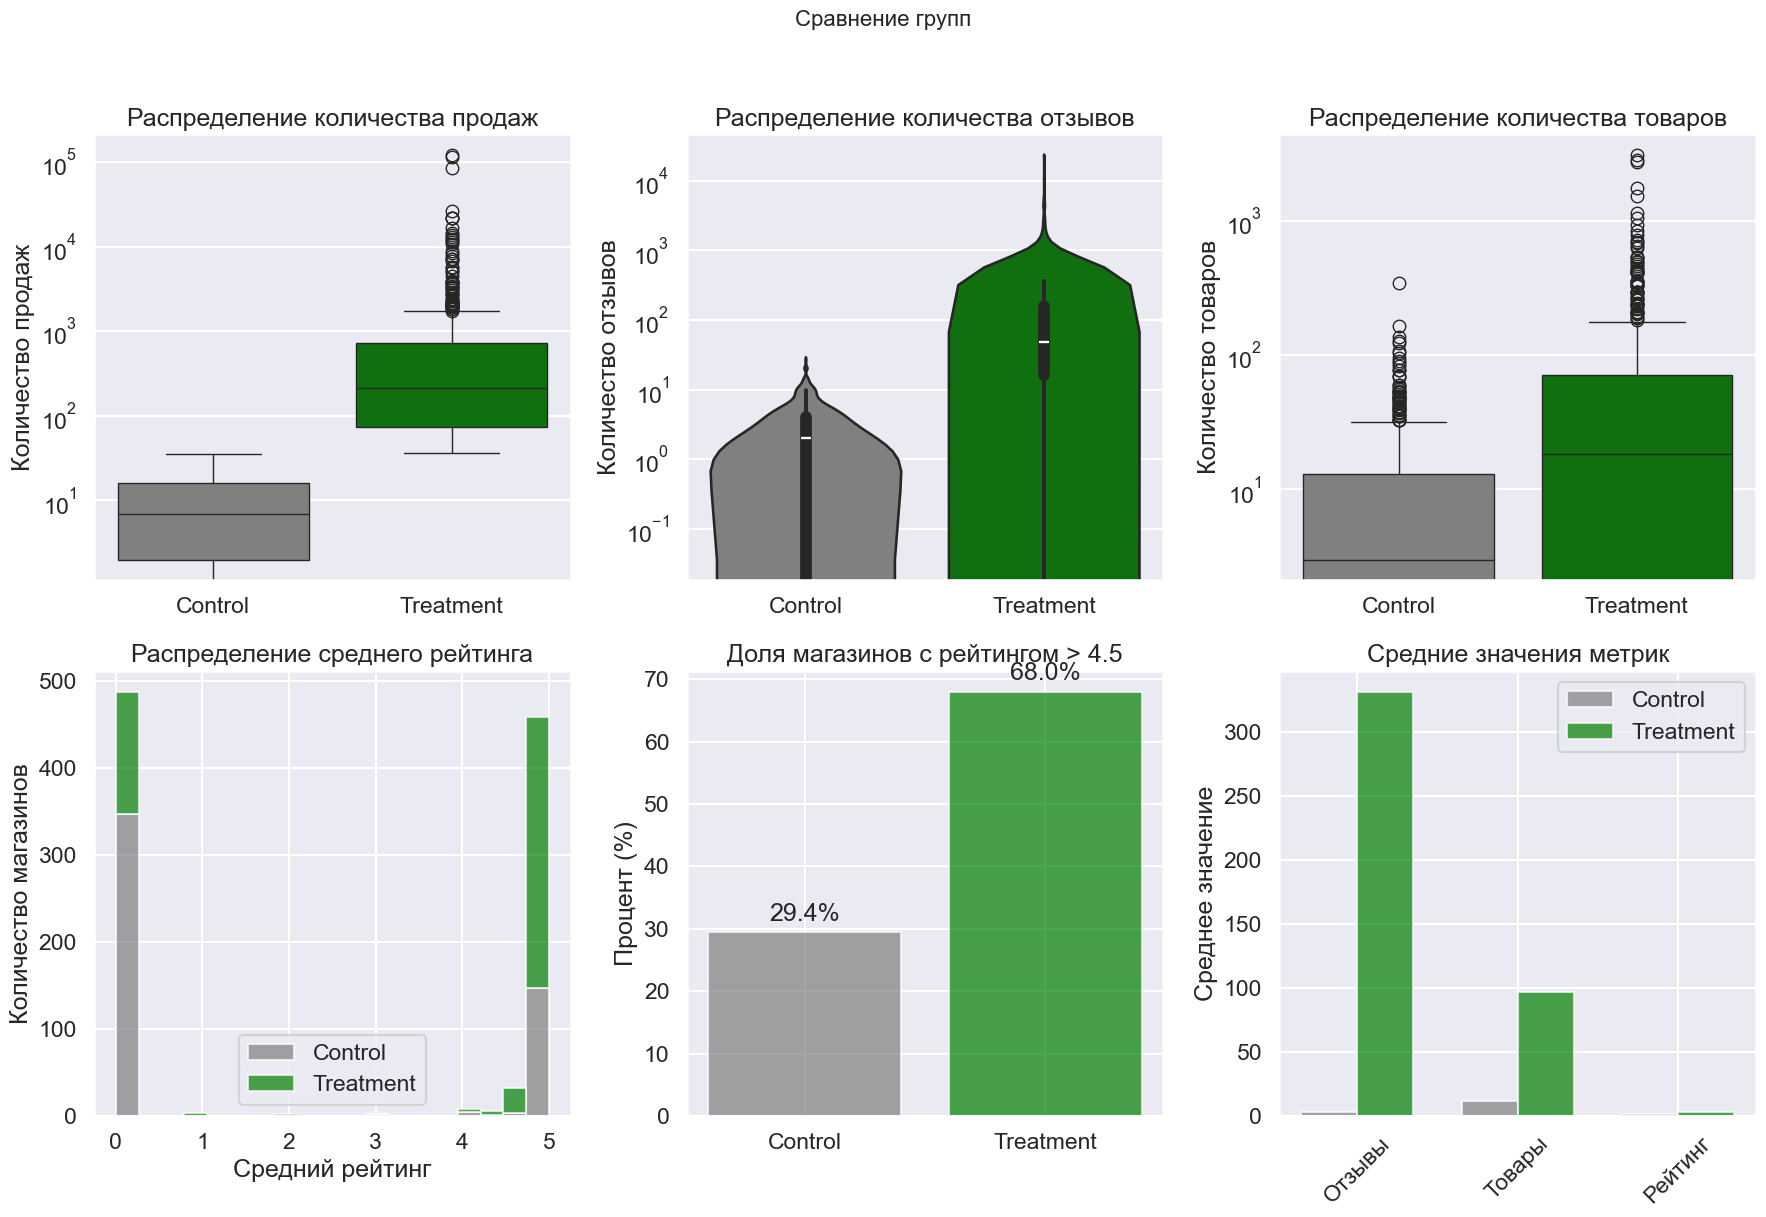

#### Расчет propensity score

Выберем ТОП-10 локаций и закодируем их в переменную "location_group"
Это нужно в рамках этого датасета, потому что:
- Много международных продавцов
- Распределение локаций сильно скошено
- Нам нужна устойчивая модель propensity score

ТОП-10 локаций покрывают 90% локаций магзинов, поэтому соблюдается баланс между информативностью и практичностью.

In [ ]:
# Подготовка признаков
feature_cols = ['number_of_reviews', 'number_of_items']

# Кодируем локацию
top_locations = data['seller_location'].value_counts().head(10).index
data['location_group'] = data['seller_location'].apply(
    lambda x: x if x in top_locations else 'Other'
)
location_dummies = pd.get_dummies(data['location_group'], prefix='loc', drop_first=True)

`t (target)` - целевая переменная

`X` - признаки для модели

`pd.get_dummies()` - преобразует категориальные переменные в дамми-переменные (one-hot encoding)

Пайплайн объединяет два шага:

`StandardScaler()` - стандартизирует признаки (вычитает среднее и делит на стандартное отклонение)

`LogisticRegression()` - обучает модель логистической регрессии

`threshold = 0.5` - порог для классификации

`df['proba']` - предсказанная вероятность propensity score

`df['logit']` - логит-преобразование вероятности: ln(p/(1-p)). ДЛЯ СПРАВКИ: Логистическая регрессия на самом деле предсказывает именно logit. Затем logit преобразуется в вероятность через сигмоиду: p = 1/(1 + e^(-logit)). Логит часто используется в статистических моделях как "нормализованная" версия вероятности. Удобен для сравнения эффектов в линейном масштабе и используется в методах propensity score matching.

`df['pred']` - бинарное предсказание (1 если вероятность ≥ 0.5, иначе 0)

In [ ]:
X = pd.concat([data[feature_cols], location_dummies], axis=1)
t = data[TREATMENT]

print(f"Признаки для модели ({len(X.columns)}):")
print(X.columns.tolist())

# %%
# Строим модель логистической регрессии
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_classifier', LogisticRegression(random_state=42, max_iter=1000))
])
pipe.fit(X, t)

threshold = 0.5
data['proba'] = pipe.predict_proba(X)[:, 1]
data['logit'] = np.log(data['proba'] / (1 - data['proba'] + 1e-10))
data['pred'] = (data['proba'] >= threshold).astype(int)

print("\nПервые строки с предсказаниями:")
data[['number_of_sales', 'treatment', 'proba', 'logit', 'pred']].head()

Мы не разделили данные на обучающую и тестовую группы, поскольку мы не строим прогностическую модель. Propensity score говорит нам о вероятности того, что человек получит treatment=1 с учетом объясняющих переменных. Мы также посмотрим на логит-преобразование показателя propensity score.

Оценим модель:

In [ ]:
print(f"Accuracy: {np.mean(data[TREATMENT]==data['pred']):.4f},\
 ROC AUC: {roc_auc_score(data[TREATMENT], data['proba']):.4f},\
 F1-score: {f1_score(data[TREATMENT], data['pred']):.4f}")
# Visualise confusion matrix
pd.crosstab(data[TREATMENT], data['pred']).rename(columns={0: False,
                                                       1:True})

#### Визуализация propensity scores

Эти графики помогают ответить на главный вопрос: "Можно ли делать matching?" Если перекрытие есть и модель работает непредвзято - можно смело переходить к следующему шагу - расчета matching.

**1 график**
- Область перекрытия (где гистограммы накладываются) - здесь должны быть объекты, похожие из обеих групп

- Если перекрытия нет - matching невозможен

- Если перекрытие большое - хорошо для matching

**2 график**
- Логит = $ln(\frac{p}{(1-p)})$ - это линейная трансформация propensity score

- Диапазон: от -∞ до +∞ (на практике обычно от -10 до 10)

**3 график**
- Медианы (линия внутри ящика): Control должна быть низкой, Treatment высокой

- Разброс: Показывает вариативность внутри групп

- Перекрытие ящиков: Чем меньше, тем лучше модель разделяет группы

- Выбросы: Объекты с необычными характеристиками

**4 график**
- Процент правильно классифицированных объектов в каждой группе

- Порог классификации: 0.5

- Идеальный случай: Control: 100% (все control правильно определены), Treatment: 100% (все treatment правильно определены)

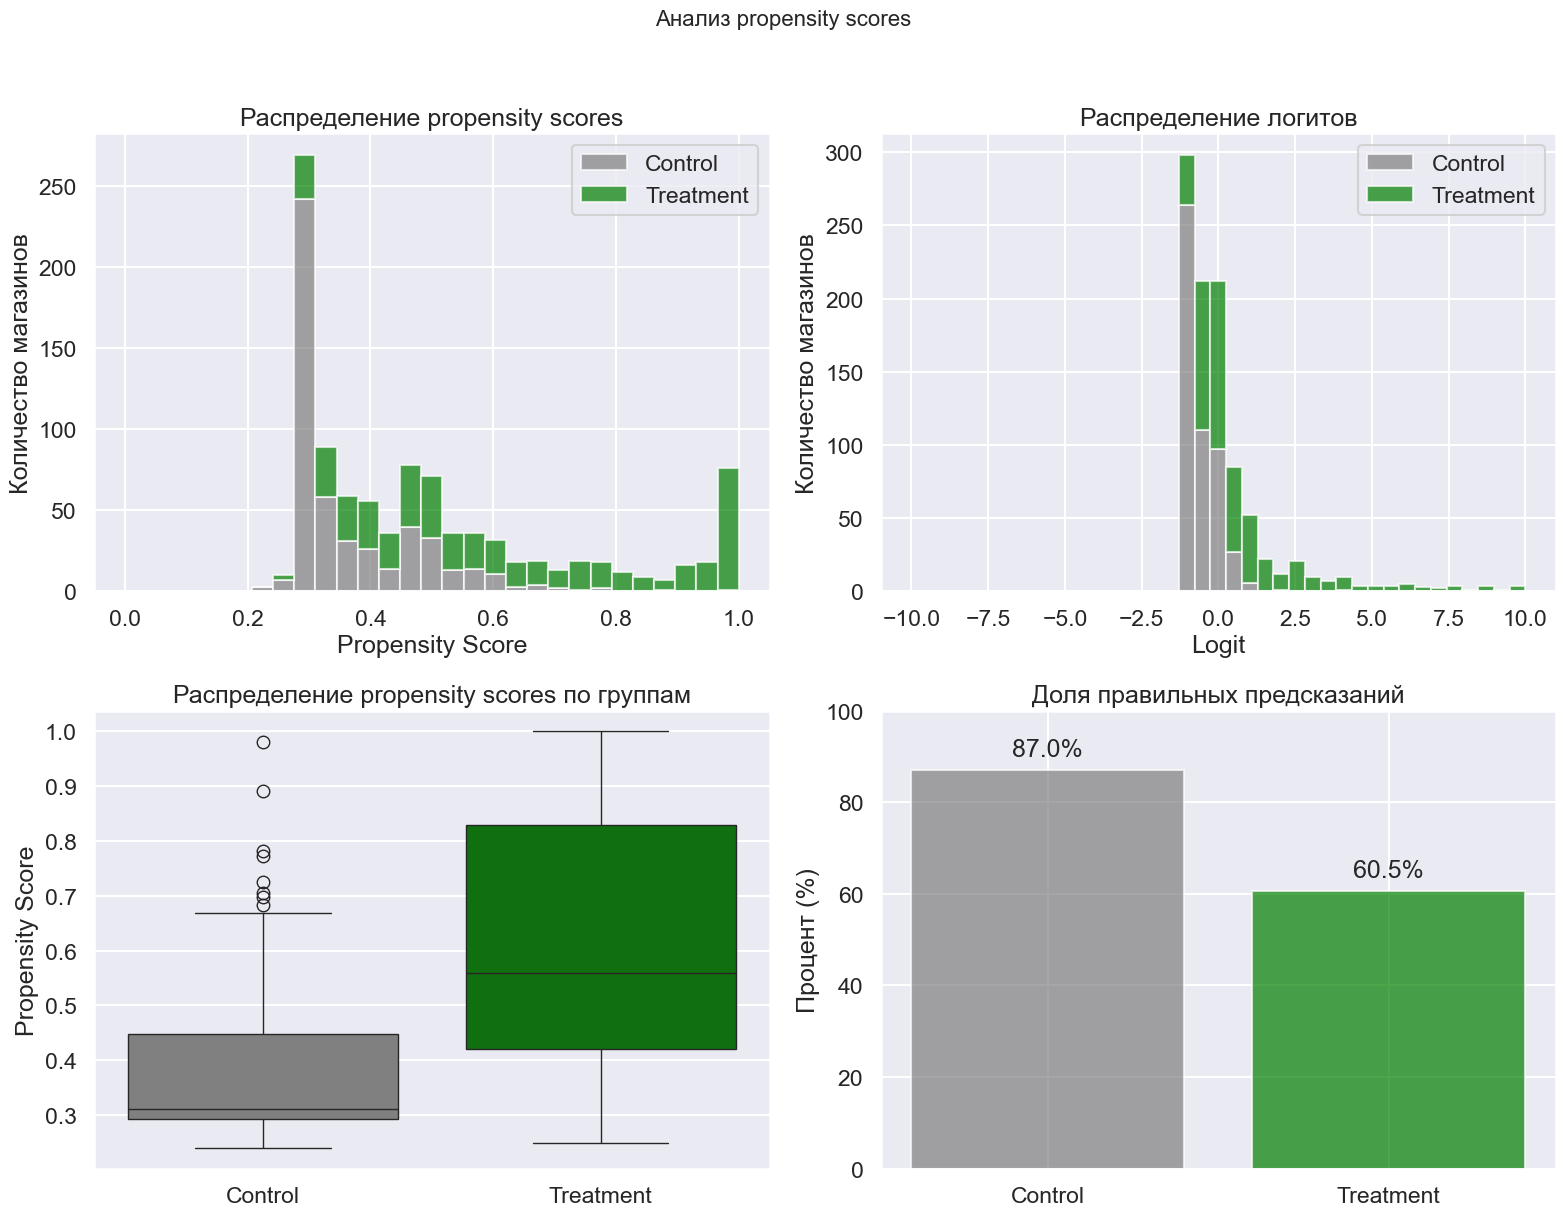

#### Метчинг

Здесь мы собираемся **сопоставить наиболее похожие наблюдения из контроля с наблюдениями в экспериментальной группе**. Найти похожие наблюдения в одном измерении (показатель склонности) намного проще, чем во многих измерениях (confounders). Propensity score — это уравновешивающая оценка. Это означает, что если мы сопоставляем наблюдения на основе оценки склонности (propensity score), распределение конфаундеров между сопоставленными записями, вероятно, будет аналогичным.

В следующем сценарии мы **находим контрольные наблюдения с наиболее похожим propensity score для каждого наблюдения в тестовой группе (соответствие 1 к 1)**. При этом мы будем делать контрольную выборку с возвращением. Это означает, что некоторые наблюдения из контроля могут сопоставляться несколько раз с разными наблюдениями тритмента, в то время как некоторые контрольные наблюдения вообще не будут сопостовимы:

In [ ]:
# Сортируем по логиту
data_sorted = data.sort_values('logit').reset_index(drop=True)
data_sorted['match'] = np.nan
data_sorted['distance'] = np.nan

n = len(data_sorted)
used_controls = set()

for i, (idx, row) in enumerate(data_sorted.iterrows()):
    if row[TREATMENT]:  # только для treatment группы
        best_match = None
        best_distance = np.inf
        best_idx = None

        # Ищем выше по списку (больший logit)
        if i < n-1:
            above_indices = range(i+1, n)
            for j in above_indices:
                candidate = data_sorted.iloc[j]
                if not candidate[TREATMENT] and candidate.name not in used_controls:
                    distance = candidate['logit'] - row['logit']
                    if distance < best_distance:
                        best_distance = distance
                        best_match = candidate
                        best_idx = j
                    break  # нашли первого подходящего выше

        # Ищем ниже по списку (меньший logit)
        if i > 0:
            below_indices = range(i-1, -1, -1)
            for j in below_indices:
                candidate = data_sorted.iloc[j]
                if not candidate[TREATMENT] and candidate.name not in used_controls:
                    distance = row['logit'] - candidate['logit']
                    if distance < best_distance:
                        best_distance = distance
                        best_match = candidate
                        best_idx = j
                    break  # нашли первого подходящего ниже

        # Если нашли подходящий control
        if best_match is not None:
            data_sorted.loc[idx, 'match'] = best_match.name
            data_sorted.loc[idx, 'distance'] = best_distance
            used_controls.add(best_match.name)

# Посмотрим результат
matched_treatment = data_sorted[data_sorted[TREATMENT]==1].dropna(subset=['match'])
print(f"Найдено соответствий: {len(matched_treatment)} из {sum(data_sorted[TREATMENT]==1)}")
matched_treatment[['logit', 'match', 'distance']].head(10)

In [ ]:
print("="*60)
print("РЕЗУЛЬТАТЫ MATCHING")
print("="*60)
print(f"Всего treatment магазинов: {sum(data_sorted[TREATMENT]==1)}")
print(f"Найдено соответствий: {len(matched_treatment)}")
print(f"Процент успешного matching: {len(matched_treatment)/sum(data_sorted[TREATMENT]==1)*100:.1f}%")

print("\nСтатистика расстояний (разница в логитах):")
print(matched_treatment['distance'].describe())

In [ ]:
matched_indices = matched_treatment.index.tolist() + \
                  matched_treatment['match'].astype(int).tolist()

matched_data = data_sorted.loc[matched_indices].copy()
matched_data = matched_data.sort_values('pair_id' if 'pair_id' in matched_data.columns else 'logit')

print(f"\nРазмер matched_data: {len(matched_data)}")
print(f"Treatment в matched_data: {sum(matched_data[TREATMENT]==1)}")
print(f"Control в matched_data: {sum(matched_data[TREATMENT]==0)}")

# Добавляем идентификатор пары
pair_dict = {}
for i, (idx, row) in enumerate(matched_treatment.iterrows()):
    pair_dict[idx] = i
    pair_dict[int(row['match'])] = i
matched_data['pair_id'] = matched_data.index.map(pair_dict)

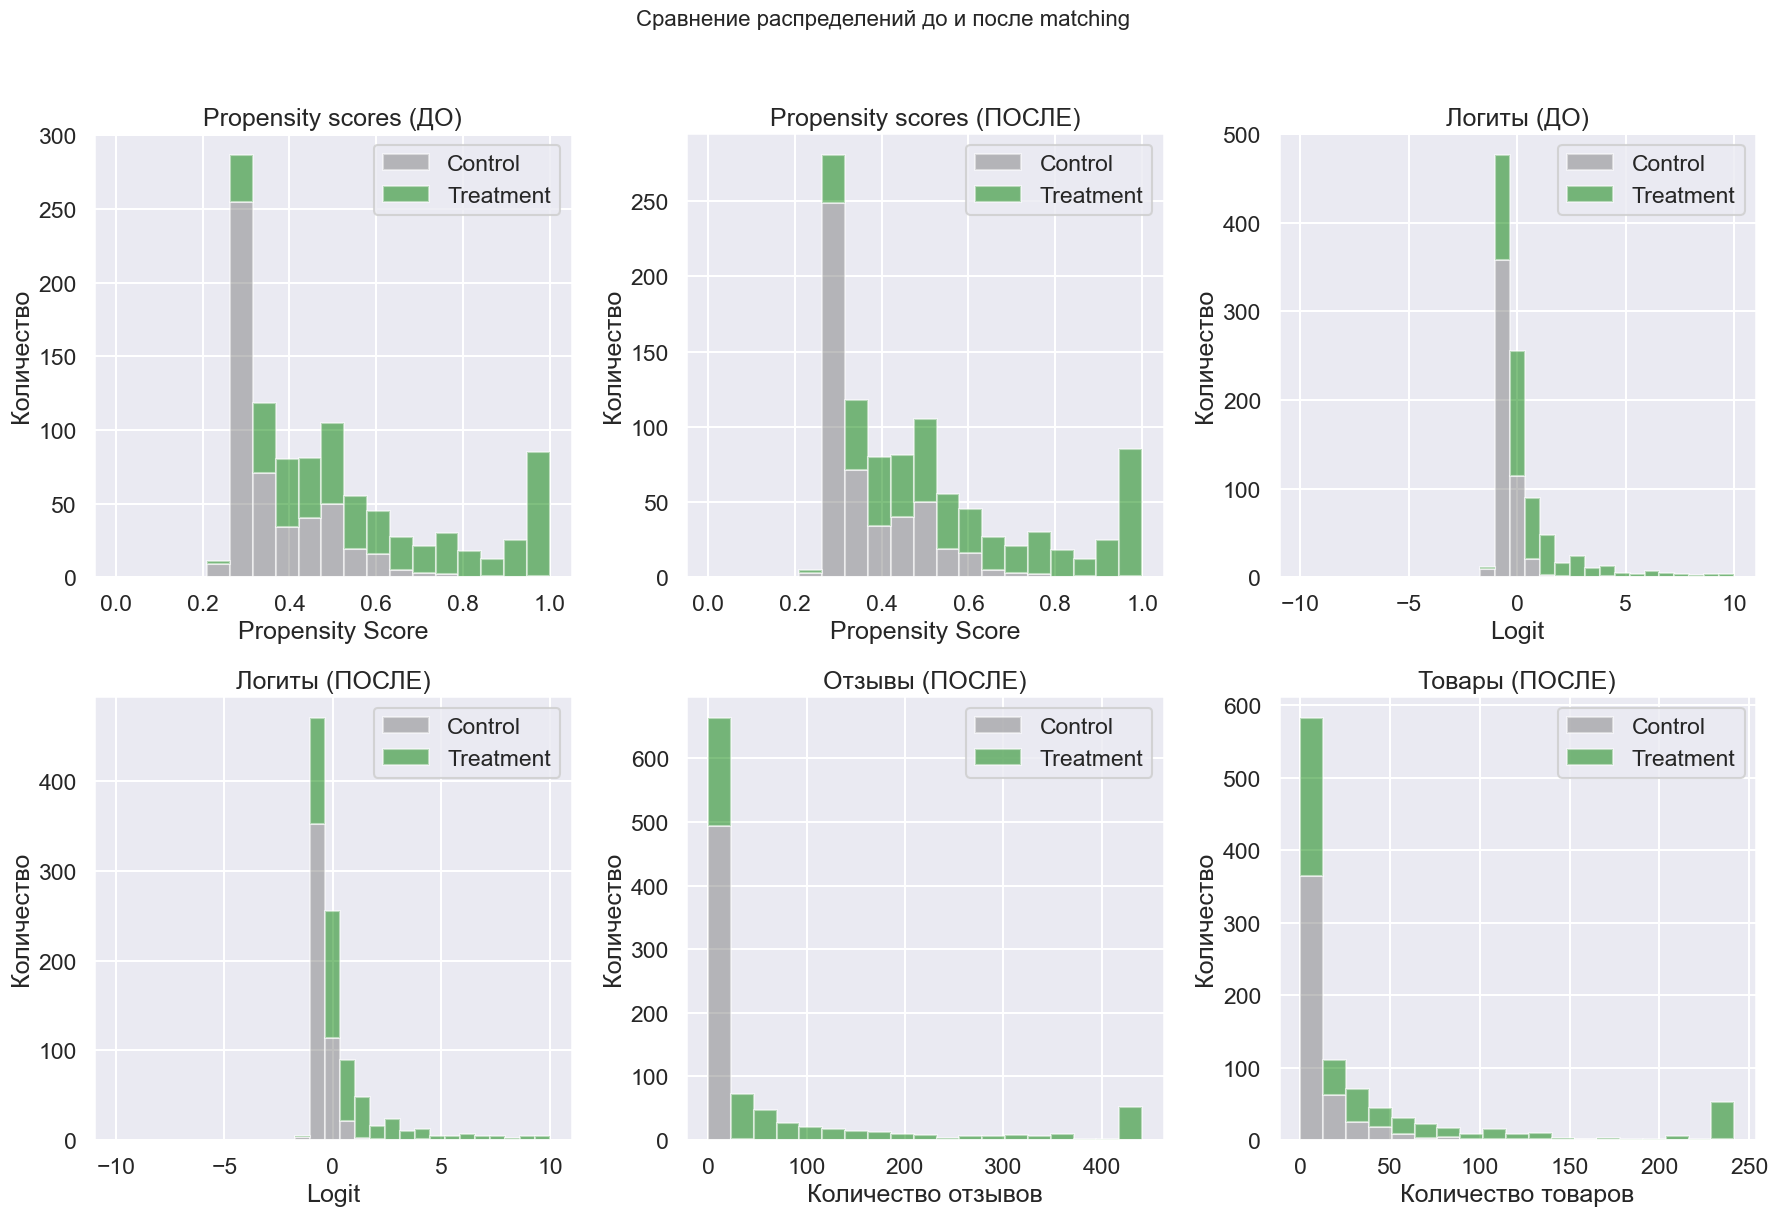

Matching прошел успешно! Теперь можно доверять расчету, потому что группы стали сопоставимы по всем важным характеристикам.

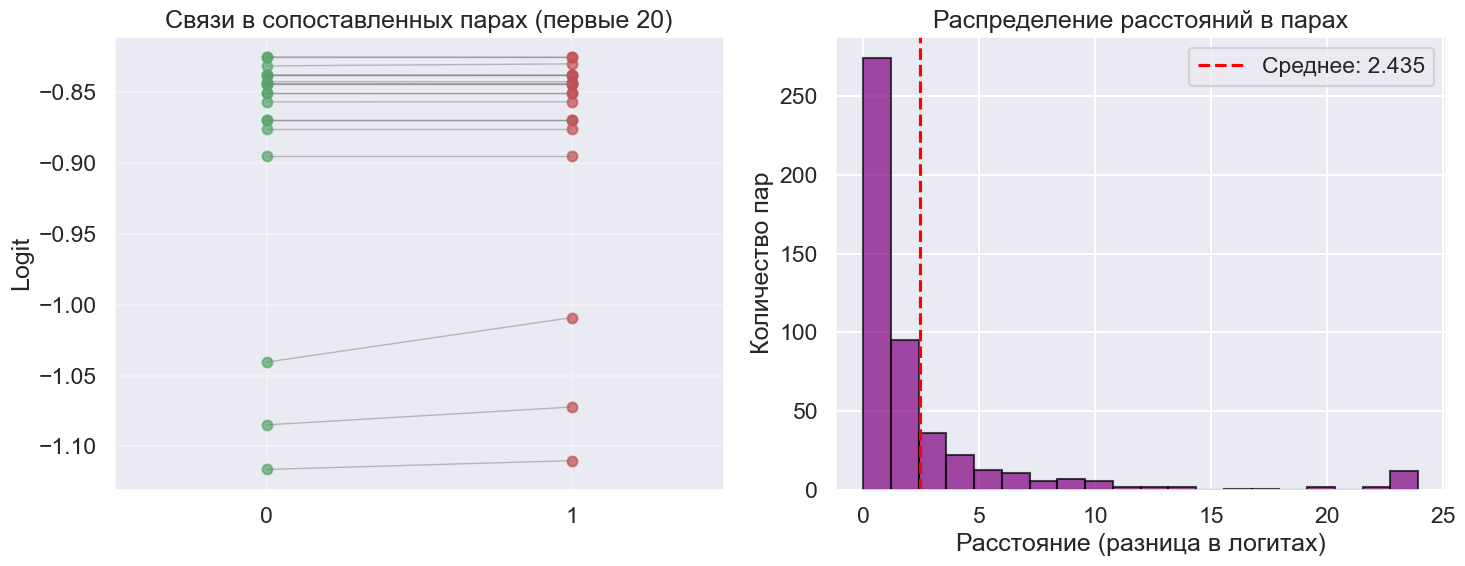

**1 график**

Каждая серая линия соединяет один treatment магазин (справа) с его control магазином (слева)

Точки - это сами магазины (серые - control, зеленые - treatment)

Вертикальная ось - значение логита (чем выше, тем больше вероятность быть в treatment группе)

**2 график**

`Форма распределения:`

Скошена влево (больше маленьких расстояний) - хорошо

Скошена вправо (много больших расстояний) - плохо

Нормальное/колокол - приемлемо

`Среднее значение:`

< 0.1 → отличное совпадение

0.1 - 0.3 → хорошее совпадение

0.3 - 0.5 → среднее совпадение

\> 0.5 → плохое совпадение

`Максимальное значение:`

Показывает, есть ли "плохие" пары с большим расхождением

####  Считаем ATE (Average Treatment Effect on Treated)

$ATE$ = $E[Y(1)-Y(0)]$

$ATT$ = $E[Y(1)-Y(0)|X,T = 1]$

Пусть $Y_i(t)$ для $(t = 0,1)$ обозначает значение целевой переменной. Для каждого наблюдения i наблюдается только $Y_i(0)$ или $Y_i(1)$, но не оба одновременно.

Пусть $X$ обозначает вектор переменных (ковариаты).

Пусть $TE_i$ обозначает индивидуальный эффект, определяемый как: $TE_i = Y_i(1) - Y_i(0)$. Если мы находим значение из контрольной группы такое, что $X_i = X_j$ (ковариаты совпадают), мы оцениваем $TE_i = Y_i(1) – Y_j(0)$

In [ ]:
summary = matched_data.groupby(TREATMENT)[OUTCOME].aggregate(['mean', 'std', 'count'])
print("Статистики по группам после matching:")
summary

In [ ]:
c_outcome = summary.loc[0, 'mean']  # для control группы (treatment=0)
t_outcome = summary.loc[1, 'mean']  # для treatment группы (treatment=1)

# Рассчитываем ATT
att = t_outcome - c_outcome

print('The Average Treatment Effect on Treated (ATT): {:.4f}'.format(att))

#### Готовая реализация

In [ ]:
y = data[OUTCOME].values
t = data[TREATMENT].values
X = data[['number_of_reviews', 'number_of_items']].values
X = StandardScaler().fit_transform(X)

# Создание и оценка модели
model = CausalModel(y, t, X)
model.est_via_matching()
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ИЗ БИБЛИОТЕКИ CAUSALINFERENCE")
print("="*60)
print(model.estimates)

ATE (Average Treatment Effect) = 1.633:

В среднем по всем магазинам (и с высокими, и с низкими продажами),
переход из группы с низкими продажами в группу с высокими продажами
увеличивает средний рейтинг на 1.633 пункта.
Статистическая значимость:
- p-value = 0.001 (< 0.05) - статистически значимо
- 95% доверительный интервал: [0.652, 2.615] (не включает 0)

ATC (Average Treatment Effect on Control) = 1.903:

Если бы магазины из контрольной группы (с низкими продажами)
получили treatment (стали бы магазинами с высокими продажами),
их средний рейтинг увеличился бы на 1.903 пункта.
Статистическая значимость:
- p-value = 0.003 (< 0.05) - статистически значимо
- 95% CI: [0.756, 3.051] (не включает 0)

ATT (Average Treatment Effect on Treated) = 1.356


Магазины с высокими продажами имеют средний рейтинг
на 1.356 пункта выше, чем если бы они были с низкими продажами.
Статистическая значимость:
- p-value = 0.082 (> 0.05) - статистически не значимо
- 95% CI: [-0.174, 2.886] (включает 0)

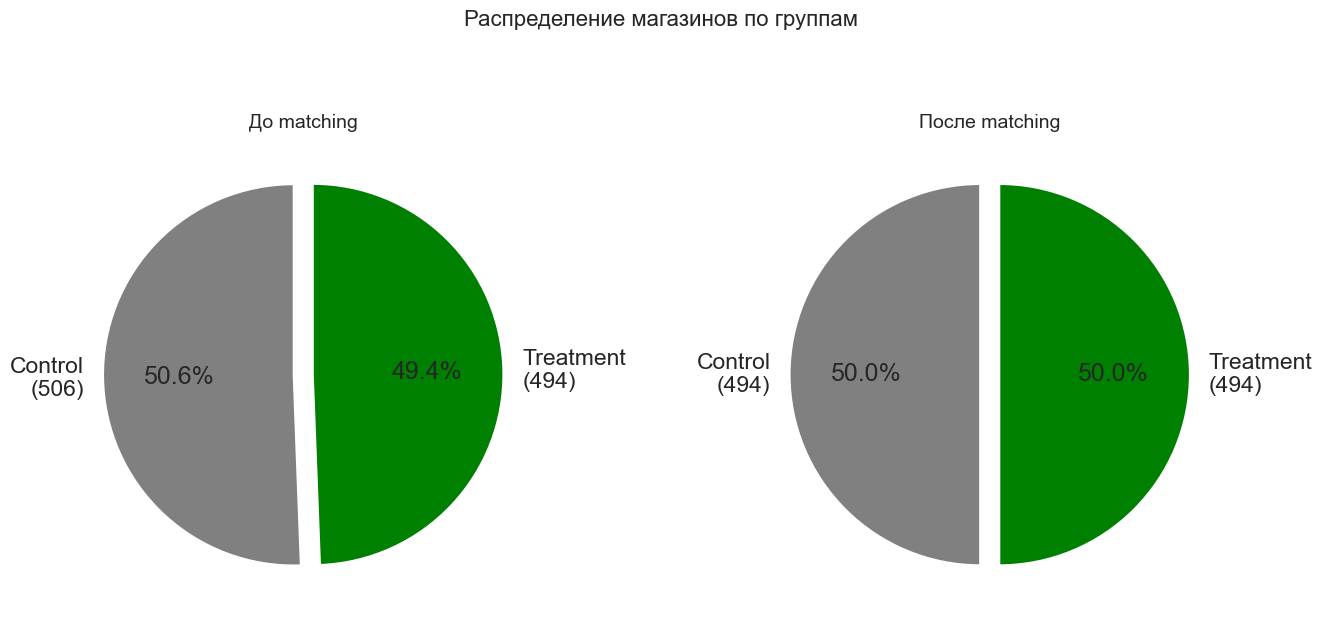

In [ ]:
pairs_preview = []
for idx, row in matched_treatment.iterrows():
    control_idx = int(row['match'])
    pairs_preview.append({
            'pair_id': idx,
            'treatment_logit': row['logit'],
            'treatment_proba': row['proba'],
            'treatment_reviews': data_sorted.loc[idx, 'number_of_reviews'],
            'treatment_rating': data_sorted.loc[idx, 'average_review_score'],
            'control_logit': data_sorted.loc[control_idx, 'logit'],
            'control_proba': data_sorted.loc[control_idx, 'proba'],
            'control_reviews': data_sorted.loc[control_idx, 'number_of_reviews'],
            'control_rating': data_sorted.loc[control_idx, 'average_review_score'],
            'distance': row['distance']
        })

pairs_df = pd.DataFrame(pairs_preview)
pairs_df

# Вопросы для проверки

**Общие вопросы:**

1. В каких случаях простой рандомизированной выборки достаточно для составления групп A/B-теста
2. Что именно дает стратифицированная выборка и для чего ее применяют?
3. Как уменьшение дисперсии при проведении A/B -теста может помочь бизнесу?

**Ответы на общие вопросы:**

1. Простой рандомизированной выборки достаточно, когда объектов много, группы изначально примерно однородны, нет сильных известных факторов, которые одновременно влияют и на попадание в группу, и на целевую метрику. Тогда случайное распределение за счёт закона больших чисел делает test и control сопоставимыми.

2. Стратифицированная выборка делит объекты на важные сегменты до разбиения на группы и сохраняет пропорции этих сегментов в test и control. Её применяют, когда есть признаки, сильно связанные с метрикой: страна, размер клиента, категория, историческая активность. Это снижает риск перекоса между группами.

3. Уменьшение дисперсии повышает чувствительность A/B-теста: тот же эффект можно обнаружить на меньшем размере выборки или за меньшее время. Для бизнеса это означает более быстрые решения, меньшие затраты на эксперимент и меньший риск пропустить полезное изменение.


**Вопросы о Propensity score:**

1. Что такое propensity score и как он рассчитывается?
2. Почему мы не можем просто сравнить средние значения treatment и control групп?
3. Что такое matching и зачем он нужен в АБ-тестах?

**Ответы о Propensity score:**

1. Propensity score — это вероятность попасть в treatment-группу при заданных наблюдаемых признаках объекта: \(P(T=1|X)\). В ноутбуке она оценивается моделью логистической регрессии по ковариатам, например числу продаж, отзывов, товаров и признакам локации.

2. Простое сравнение средних treatment и control может быть смещённым, если группы отличаются не только воздействием, но и исходными характеристиками. Например, магазины с большим числом продаж могут иметь более высокий рейтинг независимо от treatment, и тогда разница средних смешает эффект воздействия с эффектом состава групп.

3. Matching — это подбор похожих объектов из treatment и control по propensity score или близким ковариатам. В A/B-тестах и квазиэкспериментах он нужен, чтобы сравнивать максимально похожие пары и приблизить данные к ситуации, где группы различаются главным образом наличием treatment.
